In [27]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import colorsys
from matplotlib.ticker import PercentFormatter, MultipleLocator, MaxNLocator


# ============================================================
# Generate vivid distinct colors
# ============================================================
def generate_vivid_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.9
        value = 0.9
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        colors.append(rgb)
    return colors


# ============================================================
# Plot multiple result folders
# ============================================================
def plot_multiple_result_dirs(
    dir_list,
    max_event=650,
    title=None,
    legend_names=None,
    shift_list=None
):

    dir_list = [Path(d) for d in dir_list]

    # ---- legend names ----
    if legend_names is not None:
        if len(legend_names) != len(dir_list):
            raise ValueError("legend_names must match number of directories")

    # ---- shift ----
    if shift_list is None:
        shift_list = [0] * len(dir_list)

    if len(shift_list) != len(dir_list):
        raise ValueError("shift_list must match number of directories")

    colors = generate_vivid_colors(len(dir_list))

    plt.figure(figsize=(10, 6))

    has_any_curve = False
    all_eer_max = 0.0

    # ========================================================
    # Loop folders
    # ========================================================
    for dir_idx, result_dir in enumerate(dir_list):

        color = colors[dir_idx]
        shift = shift_list[dir_idx]

        legend_label = (
            legend_names[dir_idx]
            if legend_names else result_dir.name
        )

        first_plot = True

        for json_file in result_dir.glob("*.json"):

            try:
                with open(json_file, "r") as f:
                    data = json.load(f)

                if isinstance(data, dict) and ("n" in data and "avg_eer" in data):
                    n = np.array(data["n"])
                    avg_eer = np.array(data["avg_eer"])
                else:
                    # Support per-user nested JSON:
                    # {userX: {"1": {"n": 1, "EER": ...}, ...}, ...}
                    bucket = {}
                    for user_block in data.values() if isinstance(data, dict) else []:
                        if not isinstance(user_block, dict):
                            continue
                        for rec in user_block.values():
                            if not isinstance(rec, dict):
                                continue
                            n_val = rec.get("n")
                            eer_val = rec.get("EER", rec.get("avg_eer"))
                            if n_val is None or eer_val is None:
                                continue
                            bucket.setdefault(int(n_val), []).append(float(eer_val))

                    if not bucket:
                        raise ValueError("Unsupported JSON structure for plotting")

                    sorted_n = sorted(bucket.keys())
                    n = np.array(sorted_n)
                    avg_eer = np.array([np.mean(bucket[k]) for k in sorted_n])

                # x-axis uses n directly; optional shift keeps manual alignment ability
                events = n + shift

                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]

                if len(events) == 0:
                    continue

                plt.plot(
                    events,
                    avg_eer,
                    linestyle="-",
                    linewidth=2.5,
                    marker="o",
                    markersize=5,
                    color=color,
                    alpha=0.95,
                    label=legend_label if first_plot else None
                )

                has_any_curve = True
                all_eer_max = max(all_eer_max, float(np.nanmax(avg_eer)))
                first_plot = False

            except Exception as e:
                print(f"[ERROR] {json_file}: {e}")

    if not has_any_curve:
        raise ValueError(
            "No valid curves were plotted. Check directory path and JSON format (expected keys: 'n' and 'avg_eer')."
        )

    # ========================================================
    # Axis
    # ========================================================
    ax = plt.gca()
    ax.set_ylim(bottom=0)

    if all_eer_max <= 1.0:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.yaxis.set_major_locator(MultipleLocator(0.05))
    else:
        ax.yaxis.set_major_formatter(PercentFormatter(100.0))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

    ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))

    # ========================================================
    # Labels
    # ========================================================
    plt.xlabel("n", fontsize=13)
    plt.ylabel("Average EER (%)", fontsize=13)

    if title:
        plt.title(title, fontsize=14, weight="bold")
    else:
        plt.title("Multiple Result Comparison", fontsize=14, weight="bold")

    plt.grid(which='major', axis='both', linestyle='--', alpha=0.35)

    plt.legend(
        fontsize=10,
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

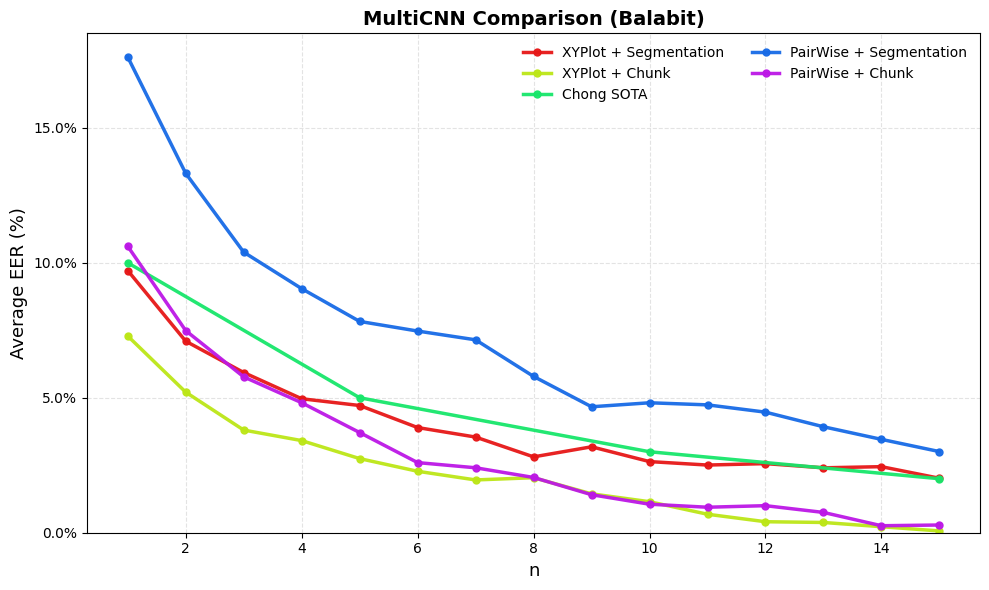

In [28]:
dir_list = [
    "Results/Chong/XYPlot_per_user",
    "Results/Chong/XYPlot_per_user+Chunk",
    "Results/Chong/SOTA",
    "Results/Chong/PairWise",
    "Results/Chong/PairWise+Chunk"
]

plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN Comparison (Balabit)",
    legend_names=["XYPlot + Segmentation", "XYPlot + Chunk", "Chong SOTA", "PairWise + Segmentation", "PairWise + Chunk"],
    shift_list=[0,0,0,0,0]
)

In [29]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Chong/per-userXYPlot_per_user/MultiCNN.json"
json_cdf = "Results/Chong/per-userXYPlot_per_user+Chunk/MultiCNN.json"

n_targets = [i+1 for i in range(5)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot + Segmentation",
    label_b="PairWise + Segmentation",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot + Segmentation),Mean EER (PairWise + Segmentation),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot + Segmentation vs PairWise + Segmentation,1,10,9.71,7.29,2.43,0.009766,True
1,XYPlot + Segmentation vs PairWise + Segmentation,2,10,7.10,5.21,1.89,0.009766,True
2,XYPlot + Segmentation vs PairWise + Segmentation,3,10,5.94,3.80,2.13,0.037109,True
3,XYPlot + Segmentation vs PairWise + Segmentation,4,10,4.96,3.41,1.55,0.027344,True
4,XYPlot + Segmentation vs PairWise + Segmentation,5,10,4.71,2.75,1.97,0.037109,True


In [30]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Chong/per-userXYPlot_per_user/MultiCNN.json"
json_cdf = "Results/Chong/per-userPairWise+Chunk/MultiCNN.json"

n_targets = [i+1 for i in range(5)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot + Segmentation",
    label_b="PairWise + Chunk",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot + Segmentation),Mean EER (PairWise + Chunk),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot + Segmentation vs PairWise + Chunk,1,10,9.71,10.61,0.90,1.000000,False
1,XYPlot + Segmentation vs PairWise + Chunk,2,10,7.10,7.49,0.39,0.845703,False
2,XYPlot + Segmentation vs PairWise + Chunk,3,10,5.94,5.77,0.16,0.431641,False
3,XYPlot + Segmentation vs PairWise + Chunk,4,10,4.96,4.82,0.15,0.492188,False
4,XYPlot + Segmentation vs PairWise + Chunk,5,10,4.71,3.71,1.00,0.193359,False


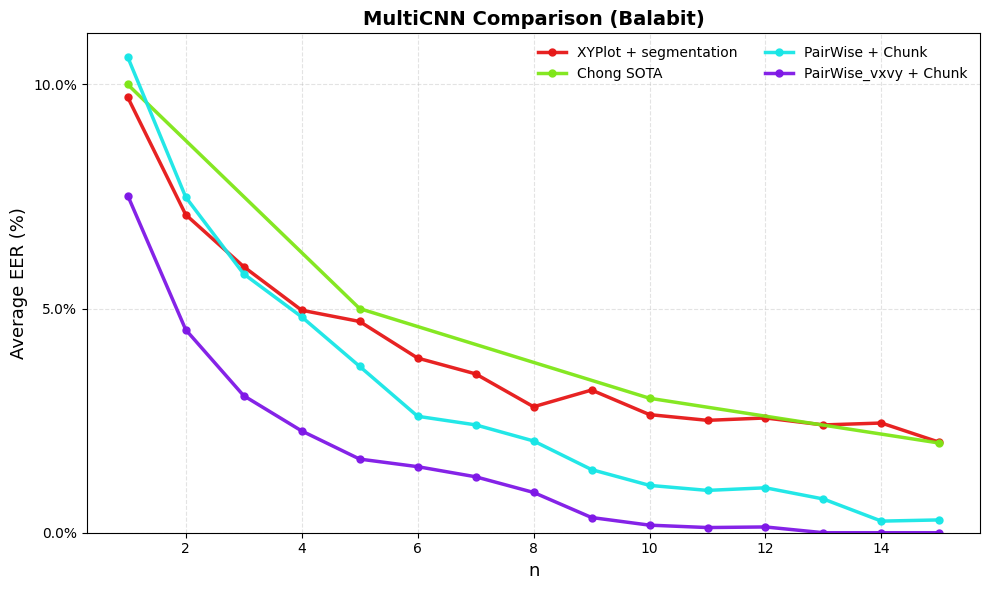

In [39]:
dir_list = [
    "Results/Chong/XYPlot_per_user",
    "Results/Chong/SOTA",
    "Results/Chong/PairWise+Chunk",
    "Results/Chong/PairWise_vxvy+Chunk"
]

plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN Comparison (Balabit)",
    legend_names=["XYPlot + segmentation", "Chong SOTA", "PairWise + Chunk", "PairWise_vxvy + Chunk"],
    shift_list=[0,0,0,0]
)

In [41]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Chong/per-userXYPlot_per_user/MultiCNN.json"
json_cdf = "Results/Chong/per-userPairWise+Chunk/MultiCNN.json"

n_targets = [i+1 for i in range(15)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot + Segmentation",
    label_b="PairWise + Chunk",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot + Segmentation),Mean EER (PairWise + Chunk),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot + Segmentation vs PairWise + Chunk,1,10,9.71,10.61,0.90,1.000000,False
1,XYPlot + Segmentation vs PairWise + Chunk,2,10,7.10,7.49,0.39,0.845703,False
2,XYPlot + Segmentation vs PairWise + Chunk,3,10,5.94,5.77,0.16,0.431641,False
3,XYPlot + Segmentation vs PairWise + Chunk,4,10,4.96,4.82,0.15,0.492188,False
4,XYPlot + Segmentation vs PairWise + Chunk,5,10,4.71,3.71,1.00,0.193359,False
5,XYPlot + Segmentation vs PairWise + Chunk,6,10,3.90,2.60,1.30,0.203125,False
6,XYPlot + Segmentation vs PairWise + Chunk,7,10,3.54,2.41,1.14,0.203125,False
7,XYPlot + Segmentation vs PairWise + Chunk,8,10,2.81,2.05,0.76,0.359375,False
8,XYPlot + Segmentation vs PairWise + Chunk,9,10,3.18,1.41,1.78,0.054688,False
9,XYPlot + Segmentation vs PairWise + Chunk,10,10,2.63,1.06,1.58,0.128906,False
